In [3]:
import seaborn as sns
import matplotlib.pyplot as plt
import pandas as pd

In [4]:
df = pd.read_csv("indigo_flights.csv")

In [3]:
df.head()

,date,airline,source,destination,scheduled_flights,cancelled_flights,flown_flights,avg_fare_inr,on_time_pct,cancellation_rate,route,is_indigo,period
0,2025-08-01,IndiGo,DEL,BOM,21,0,21,3989.0,86.7,0.0,DEL-BOM,True,normal
1,2025-08-01,IndiGo,DEL,BLR,20,2,18,3777.0,88.3,0.1,DEL-BLR,True,normal
2,2025-08-01,IndiGo,BOM,BLR,14,0,14,2478.0,89.9,0.0,BOM-BLR,True,normal
3,2025-08-01,IndiGo,DEL,CCU,13,0,13,5519.0,83.6,0.0,DEL-CCU,True,normal
4,2025-08-01,IndiGo,BOM,HYD,14,0,14,4300.0,81.4,0.0,BOM-HYD,True,normal


In [4]:
df["date"] = pd.to_datetime(df["date"])

In [5]:
df.dtypes

date                 datetime64[ns]
airline                      object
source                       object
destination                  object
scheduled_flights             int64
cancelled_flights             int64
flown_flights                 int64
avg_fare_inr                float64
on_time_pct                 float64
cancellation_rate           float64
route                        object
is_indigo                      bool
period                       object
dtype: object

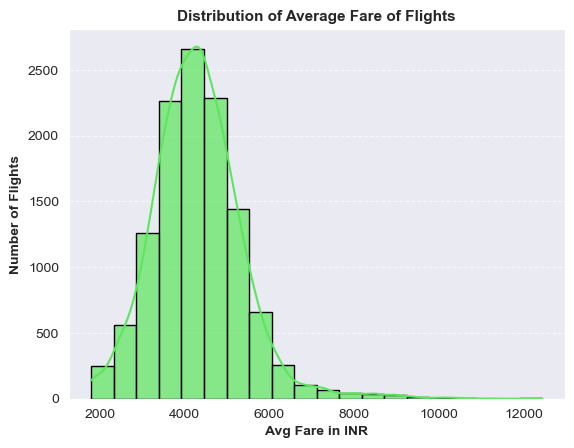

In [34]:
sns.set_style("dark")
sns.histplot(
    df["avg_fare_inr"],
    bins=20,
    kde=True,
    color="#5CE65C",
    edgecolor="black",
    alpha=0.7,
    linewidth=1
)
plt.title("Distribution of Average Fare of Flights", fontweight="bold", fontsize=11)
plt.xlabel("Avg Fare in INR", fontsize=10, fontweight="bold")
plt.ylabel("Number of Flights", fontsize=10, fontweight="bold")

plt.grid(axis="y", linestyle="--", alpha=0.7)
plt.show()

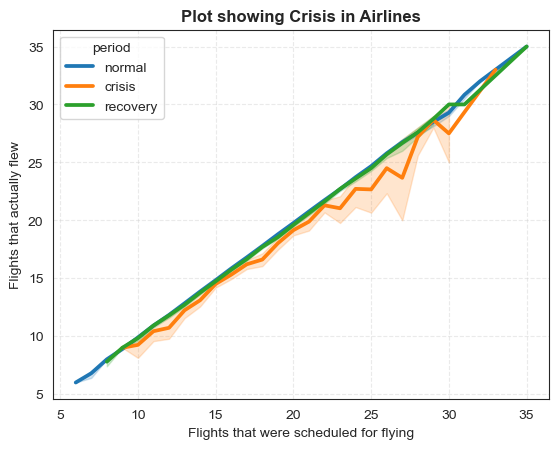

In [67]:
sns.set_style("white")
sns.lineplot(
    data=df,
    x="scheduled_flights",
    y="flown_flights",
    hue="period",
    linewidth=2.7,
)

plt.title("Plot showing Crisis in Airlines", fontweight="bold")
plt.xlabel("Flights that were scheduled for flying")
plt.ylabel("Flights that actually flew")
plt.grid(True, linestyle="--", alpha=0.4)
plt.show()

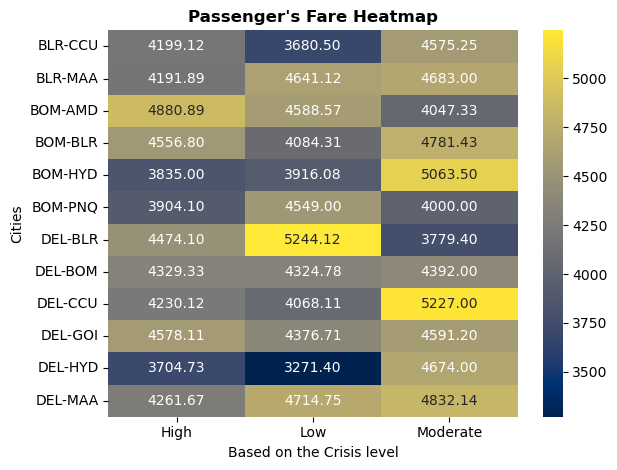

In [110]:
df2 = pd.read_csv("IndiGo_Cleaned_Data.csv")


df2_pivot = df2.pivot_table(index="route", columns="crisis_severity", values="avg_fare_inr")
sns.heatmap(
    df2_pivot,
    cmap="cividis",
    annot=True,
    fmt=".2f"
)

plt.title("Passenger's Fare Heatmap",  fontweight="bold")
plt.ylabel("Cities", fontsize= 10)
plt.xlabel("Based on the Crisis level", fontsize=10)
plt.tight_layout()
plt.show()

In [90]:
df.columns

Index(['date', 'airline', 'source', 'destination', 'scheduled_flights',
       'cancelled_flights', 'flown_flights', 'avg_fare_inr', 'on_time_pct',
       'cancellation_rate', 'route', 'is_indigo', 'period'],
      dtype='object')

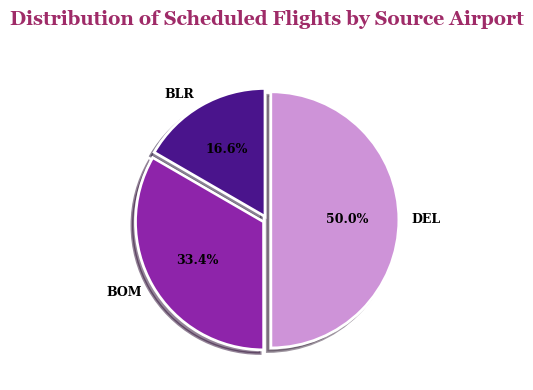

In [37]:
fig, ax=plt.subplots(figsize=(4,4))
source_city = df.groupby("source")["scheduled_flights"].sum()
colors= ["#4A148C", "#8E24AA", "#CE93D8"]
plt.pie(
    source_city,
    labels=source_city.index,
    colors=colors,
    autopct="%1.1f%%",
    startangle=90,
    explode=[0.03, 0.03, 0.03],
    shadow=True,
    wedgeprops={"edgecolor":"white", "linewidth":2},
    textprops={"fontsize":9, "color":"black", "fontweight": "bold", "fontfamily": "serif"},
)
plt.title("Distribution of Scheduled Flights by Source Airport", fontfamily= "Georgia", color="#9F2B68", fontsize=14, fontweight="bold", pad=25)
plt.tight_layout()
plt.show()


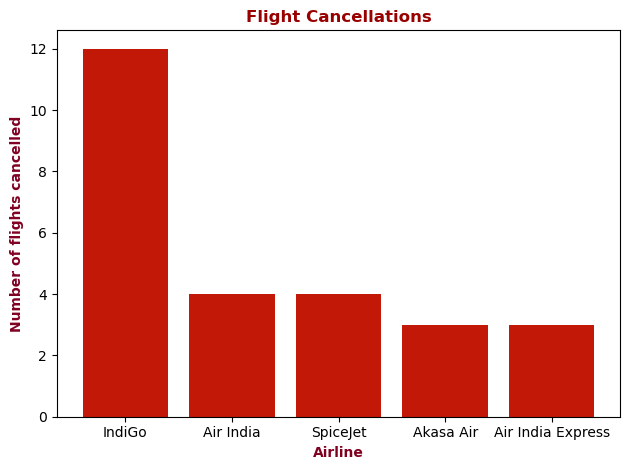

In [36]:
plt.style.use('default')
plt.bar(df["airline"], df["cancelled_flights"], color="#C21807")
plt.title("Flight Cancellations", fontweight="bold", color="#990000") #crimson red
plt.xlabel("Airline", color="#800020", fontweight="bold") 
plt.ylabel("Number of flights cancelled", color="#800020", fontweight="bold")
plt.tight_layout()
plt.show()